# Supply Chain Analytics - Demand Forecasting

## Objective

The objective of this notebook is to develop a time-series forecasting model to predict future daily sales.

Demand forecasting helps businesses improve inventory planning, reduce stock shortages, and optimize supply chain operations.

This notebook begins by preparing the daily sales time series that will be used for forecasting.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "../data/cleaned/retail_store_inventory_cleaned.csv",
    parse_dates=["Date"])

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
daily_sales = (df.groupby("Date")["Units Sold"]
      .sum()
      .reset_index())

daily_sales.head()

,Date,Units Sold
0,2022-01-01,14484
1,2022-01-02,13415
2,2022-01-03,13681
3,2022-01-04,14084
4,2022-01-05,12572


## Daily Sales Trend

Before building forecasting models, it is important to visualize the historical demand pattern.

The following plot illustrates how daily sales change over time and provides an initial understanding of trends and fluctuations.

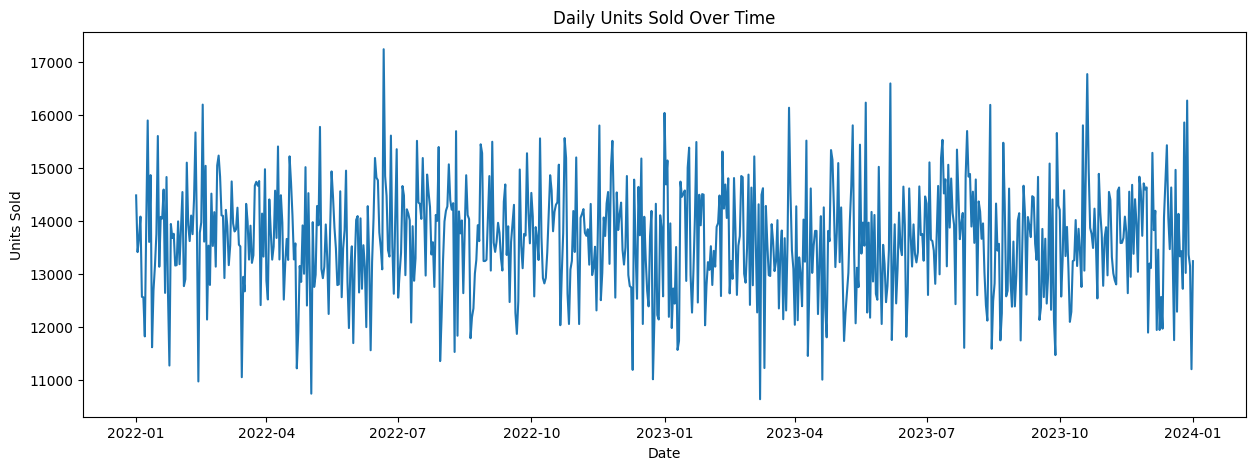

In [4]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Units Sold"])

plt.title("Daily Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()